<a href="https://colab.research.google.com/github/chamarairesh1982/LearnPython/blob/main/chamara_Week_4_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Load and Explore the Data
**Step 1) Import libraries and load the dataset**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in Titanic dataset
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']]

# 'age' has missing values for some passengers - drop those rows
df = df.dropna(subset=['age'])

print(df.shape)
print(df.head())
print(df['survived'].value_counts())


(714, 7)
   survived  pclass     sex   age     fare  sibsp  parch
0         0       3    male  22.0   7.2500      1      0
1         1       1  female  38.0  71.2833      1      0
2         1       3  female  26.0   7.9250      0      0
3         1       1  female  35.0  53.1000      1      0
4         0       3    male  35.0   8.0500      0      0
survived
0    424
1    290
Name: count, dtype: int64


**Step 2) Visualize survival by passenger class and sex**

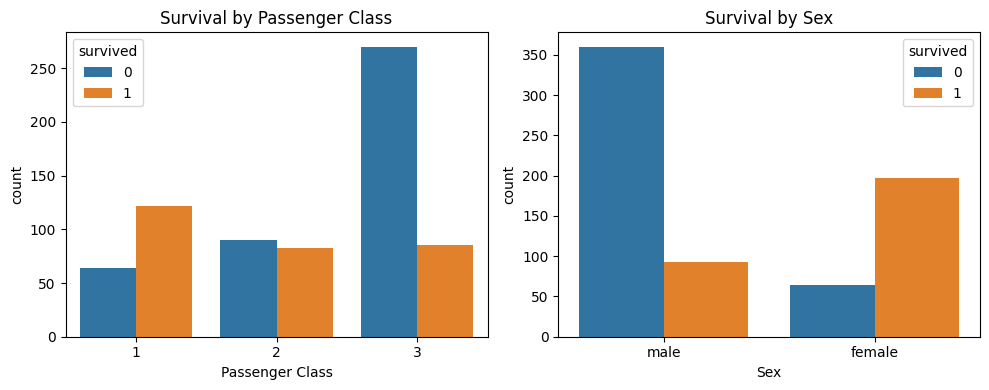

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(data=df, x='pclass', hue='survived', ax=axes[0])
axes[0].set_title('Survival by Passenger Class')
axes[0].set_xlabel('Passenger Class')

sns.countplot(data=df, x='sex', hue='survived', ax=axes[1])
axes[1].set_title('Survival by Sex')
axes[1].set_xlabel('Sex')

plt.tight_layout()
plt.show()


# Why Not Just Use Linear Regression?
It is tempting to fit an ordinary LinearRegression straight to the 0/1 outcome. Let's try it with 'fare' as the input and see what goes wrong.

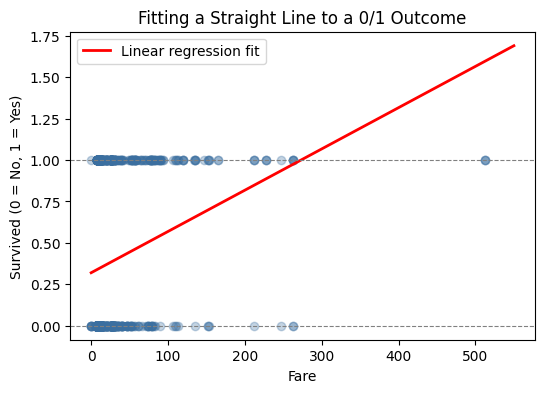

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['fare']].values
y = df['survived'].values

lr = LinearRegression()
lr.fit(X, y)

X_range = np.linspace(0, 550, 200).reshape(-1, 1)
y_range_pred = lr.predict(X_range)

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.3, color='#3b6fa0')
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Linear regression fit')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axhline(1, color='gray', linewidth=0.8, linestyle='--')
plt.title('Fitting a Straight Line to a 0/1 Outcome')
plt.xlabel('Fare'); plt.ylabel('Survived (0 = No, 1 = Yes)'); plt.legend()
plt.show()


# Fit a Logistic Regression Model (Single Feature)
Logistic regression predicts the probability of the positive class using the sigmoid function: P(y=1) = 1 / (1 + e^-(b0 + b1*x)). scikit-learn handles the fitting for us.

Accuracy: 0.6573426573426573


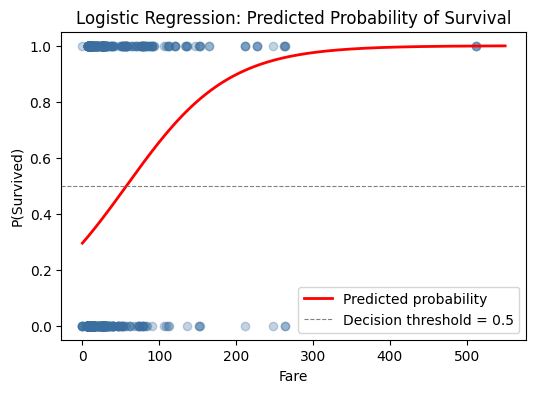

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

# Plot the predicted probability curve to see the S-shape
X_range = np.linspace(0, 550, 300).reshape(-1, 1)
y_prob = log_reg.predict_proba(X_range)[:, 1]

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.3, color='#3b6fa0')
plt.plot(X_range, y_prob, color='red', linewidth=2, label='Predicted probability')
plt.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', label='Decision threshold = 0.5')
plt.title('Logistic Regression: Predicted Probability of Survival')
plt.xlabel('Fare'); plt.ylabel('P(Survived)'); plt.legend()
plt.show()



# Full Model with Multiple Features
One feature rarely tells the whole story. Add passenger class, sex, age, fare, siblings/spouses aboard (sibsp) and parents/children aboard (parch). Since 'sex' is text, encode it as a number first.

Accuracy: 0.8041958041958042
                 precision    recall  f1-score   support

Did not survive       0.84      0.84      0.84        85
       Survived       0.76      0.76      0.76        58

       accuracy                           0.80       143
      macro avg       0.80      0.80      0.80       143
   weighted avg       0.80      0.80      0.80       143



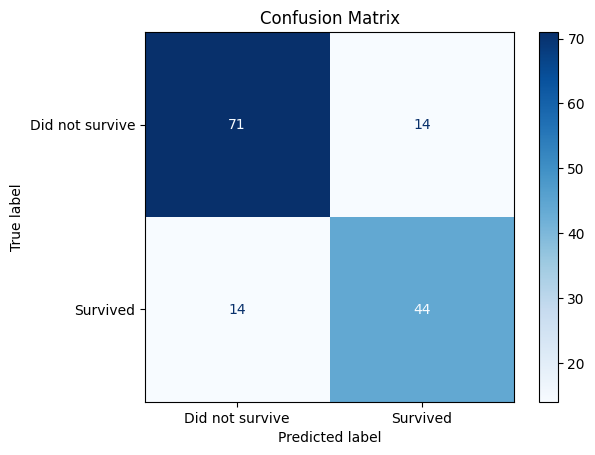

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Encode 'sex' as a numeric feature (0 = male, 1 = female)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df[['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=['Did not survive', 'Survived']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


It is also useful to look at which features push the prediction toward survival and which push against it.

pclass   -1.223549
sibsp    -0.334642
age      -0.044407
parch    -0.005183
fare      0.001403
sex       2.429122
dtype: float64


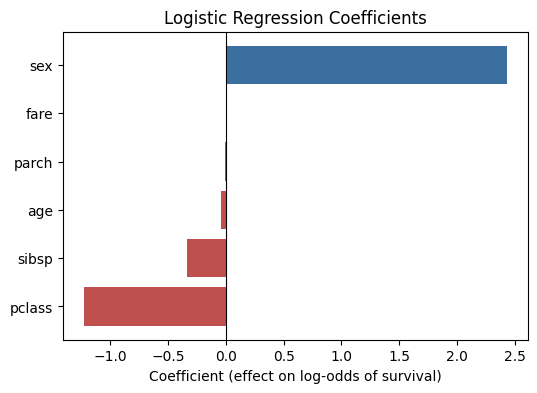

In [ ]:
coeffs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
print(coeffs)

plt.figure(figsize=(6,4))
colors = ['#c0504d' if v < 0 else '#3b6fa0' for v in coeffs.values]
plt.barh(coeffs.index, coeffs.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient (effect on log-odds of survival)')
plt.show()


# ROC Curve and Choosing a Threshold

By default, LogisticRegression classifies a passenger as 'survived' whenever the predicted probability is at least 0.5. The ROC curve shows how the true positive rate and false positive rate trade off as that threshold changes, across every possible threshold at once.

AUC: 0.863184584178499


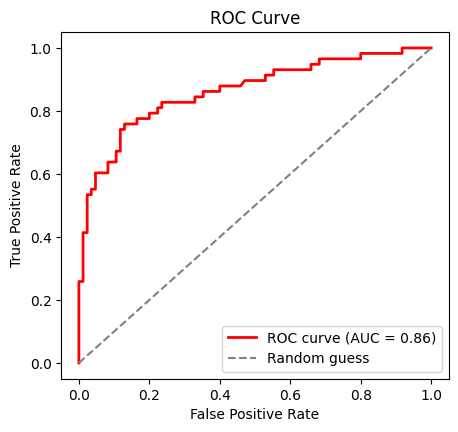

threshold=0.3: precision=0.65, recall=0.83
threshold=0.5: precision=0.76, recall=0.76
threshold=0.7: precision=0.94, recall=0.53


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score

y_prob = log_reg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print('AUC:', auc)

plt.figure(figsize=(5,4.5))
plt.plot(fpr, tpr, color='red', linewidth=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.show()

# Now see what happens to precision and recall as we move the decision threshold
for t in [0.3, 0.5, 0.7]:
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f'threshold={t}: precision={p:.2f}, recall={r:.2f}')

